# CAMM Hackathon 15: Vector Field Problem - NanoLithography


- In scanning-probe nanolithography, a biased AFM tip can switch ferroelectric polarization not only through voltage amplitude, but also through the geometry of its motion.
- The tip trajectory creates an effective in-plane electric-field pattern that can guide local switching and stabilize designed domain configurations.

Examples:

[Vasudevan, R.; et al. On-demand nanoengineering of in-plane ferroelectric topologies](https://www.nature.com/articles/s41565-024-01792-1)

[Vasudevan R., et al. Deterministic arbitrary switching of polarization in a ferroelectric thin film](https://www.nature.com/articles/ncomms5971)

####Today, we are going to focus on **designing lithography trajectories** that generate target electric-field patterns in a minimal ferroelectric model.



We consider a sharp, electrically biased probe moving across a ferroelectric surface. As the probe moves, it can locally switch the material’s polarization, making the lithography trajectory itself part of the design problem.

Two key assumptions define the simplified model:

- A moving probe creates an effective trailing in-plane field in its wake. The local polarization tends to align with the direction of probe motion.
- At each moment, you control two main parameters: the probe position or path, and the applied voltage (V). In a more complete model, the probe speed could also be included, since it affects domain-growth dynamics and therefore the final written pattern.

In this simplified challenge, the effective writing field is approximated as


$\;\mathbf{E}_{\text{eff}} = V\cdot\hat{\mathbf t}\;$

where ($\hat{\mathbf t}$) is the local travel direction of the probe. The direction of motion sets the field orientation, the voltage sets its sign and strength, and larger ($|V|$) switches a wider region of the material.

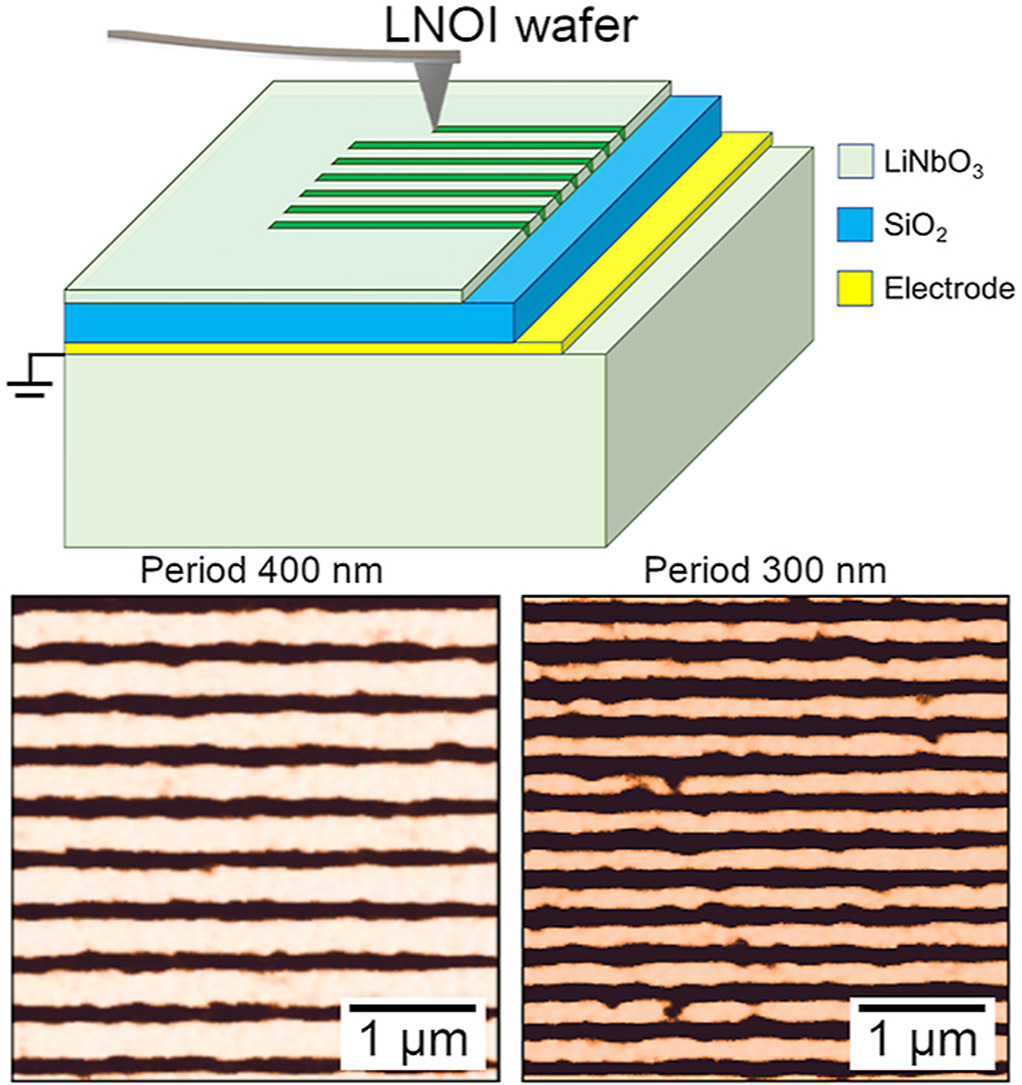

*https://www.sciencedirect.com/science/article/pii/S0272884221025785

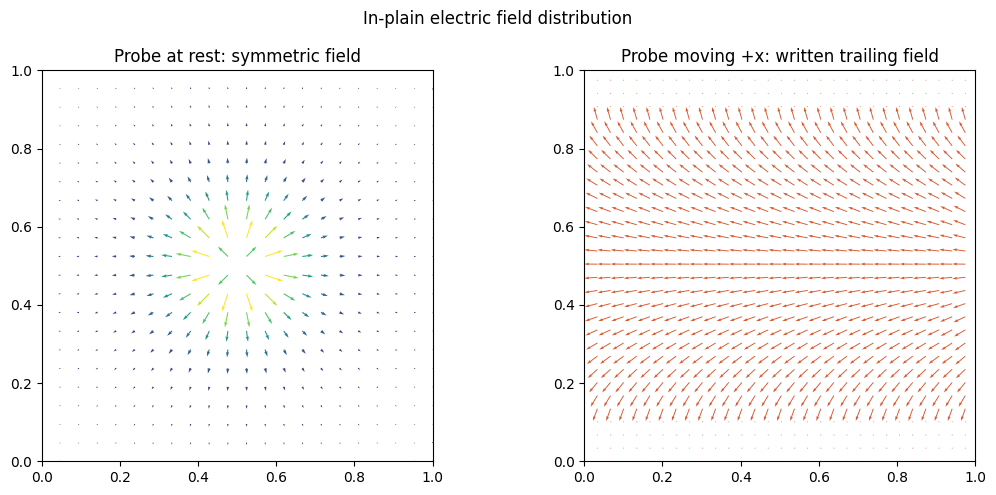

In [1]:
import numpy as np, matplotlib.pyplot as plt

h = 0.10                                   # pen (point-charge) height above the surface
def E(X, Y, xc, yc):                       # in-plane surface field from a charge at (xc, yc, h)
    dx, dy = X - xc, Y - yc
    r3 = (dx*dx + dy*dy + h*h)**1.5
    return dx/r3, dy/r3

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# --- AT REST: charge sits at the centre -> symmetric field, no chosen direction ---
g = np.linspace(0, 1, 22); X, Y = np.meshgrid(g, g)
Ex, Ey = E(X, Y, 0.5, 0.5)
ax[0].quiver(X, Y, Ex, Ey, np.hypot(Ex, Ey), cmap="viridis", scale=800)
ax[0].set_title("Probe at rest: symmetric field")

# --- MOVING +x: the spot that switches LAST is written (overwrite) -> a trailing wake ---
gg = np.linspace(0, 1, 120); Xs, Ys = np.meshgrid(gg, gg)
Px = np.zeros_like(Xs); Py = np.zeros_like(Xs); Ec = 6.0     # switching threshold
for xc in np.linspace(-0.25, 1.25, 300):                     # pen sweeps left -> right
    ex, ey = E(Xs, Ys, xc, 0.5); m = np.hypot(ex, ey); sw = m > Ec
    Px[sw], Py[sw] = ex[sw]/m[sw], ey[sw]/m[sw]              # last write wins
s = slice(None, None, 4)
ax[1].quiver(Xs[s, s], Ys[s, s], Px[s, s], Py[s, s], color="#D85A30", scale=30)
ax[1].set_title("Probe moving +x: written trailing field")

for a in ax: a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.suptitle('In-plain electric field distribution')
plt.tight_layout(); plt.show()

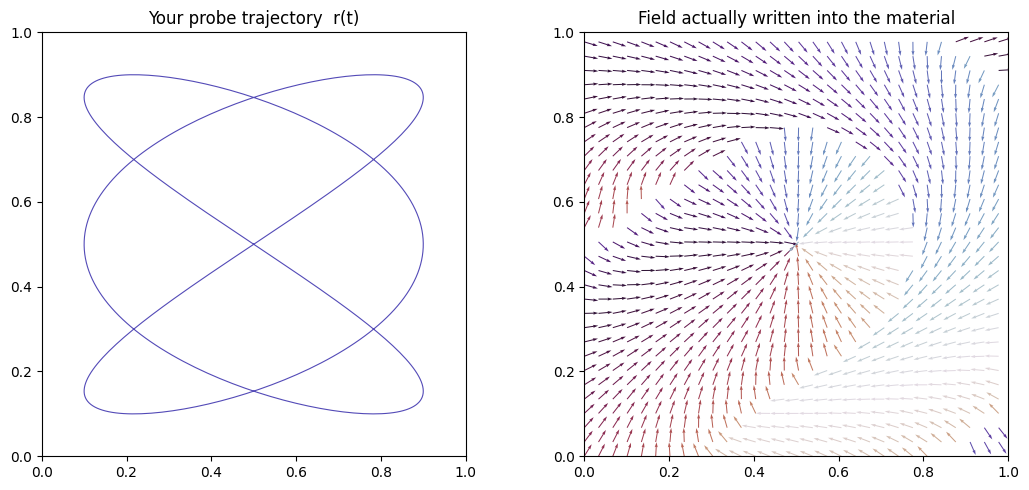

In [2]:
import numpy as np, matplotlib.pyplot as plt

h, Ec = 0.06, 12.0                         # pen height above surface, switching threshold
def Efield(X, Y, xc, yc, V):               # in-plane field of the charged pen (V scales it)
    dx, dy = X - xc, Y - yc; r3 = (dx*dx + dy*dy + h*h)**1.5
    return V*dx/r3, V*dy/r3

# ---- YOUR design: path r(t) + voltage V(t)  (sign of V = direction, |V| = brush width) ----
t = np.linspace(0, 1, 500)
def path(t): return 0.5 + 0.40*np.sin(2*np.pi*3*t), 0.5 + 0.40*np.sin(2*np.pi*2*t)
def volt(t): return np.where(t < 0.5, 1.0, -1.0)        # e.g. flip the sign halfway
xc, yc = path(t); V = volt(t)

# ---- write into the film: move the pen; the last above-threshold field wins (overwrite) ----
g = np.linspace(0, 1, 90); X, Y = np.meshgrid(g, g)
Px = np.full_like(X, np.nan); Py = np.full_like(X, np.nan)
for i in range(len(t)):
    ex, ey = Efield(X, Y, xc[i], yc[i], V[i]); m = np.hypot(ex, ey); sw = m > Ec
    Px[sw], Py[sw] = ex[sw]/m[sw], ey[sw]/m[sw]

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].plot(xc, yc, lw=.8, c="#534AB7"); ax[0].set_title("Your probe trajectory  r(t)")
s = slice(None, None, 3)
ax[1].quiver(X[s,s], Y[s,s], Px[s,s], Py[s,s], np.arctan2(Py, Px)[s,s],
             cmap="twilight", scale=30)
ax[1].set_title("Field actually written into the material")
for a in ax: a.set_aspect("equal"); a.set_xlim(0, 1); a.set_ylim(0, 1)
plt.tight_layout(); plt.show()

### Possible Problems to be Solves


#### **1. Prompt-to-trajectory generation**

Develop a system that converts a user request into a lithography trajectory.
For example, given prompts such as “write a vortex,” “create a centre-divergent pattern,” or “make a dense array of flux-closure-like structures,” the system should generate a probe path (x(t), y(t)) and voltage profile (V(t)).

#### 2. **Forward simulation of the written pattern (high complexity)**

Build a simplified model that predicts the resulting in-plane polarization or electric-field pattern from a proposed trajectory.
The model does not need to describe the full probe–sample physics, but should capture the main idea: probe motion defines the local field direction, voltage defines switching strength and sign, and material response can be approximated through simple parameters such as permittivity or switching width.

#### 3. **Trajectory optimization**

Given a target structure type and constraints, optimize the trajectory parameters.
Possible objectives include improving pattern quality, increasing feature density, reducing writing time, minimizing voltage exposure, or matching a desired domain size.

#### 4. **Inverse design from a target pattern**

Solve the inverse problem: given a desired vector-field image/pattern, generate a trajectory that could approximately write it.


The solution can be implemented either as an agentic system or as any other algorithmic approach.

In [3]:
#your code